## Multiclass Classification with SVM

The same Landsat classification task approached with support vector machines, using scikit-learn's [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) and evaluated with `classification_report` and `confusion_matrix` from `sklearn.metrics`. Results are compared against the logistic regression notebook in this folder.


## About the dataset

The database consists of the multi-spectral values of pixels in 3x3 neighbourhoods in a satellite image, and the classification associated with the central pixel in each neighbourhood. The aim is to predict this classification, given the multi-spectral values. In the sample database, the class of a pixel is coded as a number.

The Landsat satellite data is one of the many sources of information available for a scene. The interpretation of a scene by integrating spatial data of diverse types and resolutions including multispectral and radar data, maps indicating topography, land use etc. is expected to assume significant importance with the onset of an era characterised by integrative approaches to remote sensing (for example, NASA's Earth Observing System commencing this decade). Existing statistical methods are ill-equipped for handling such diverse data types. Note that this is not true for Landsat MSS data considered in isolation (as in this sample database). This data satisfies the important requirements of being numerical and at a single resolution, and standard maximum-likelihood classification performs very well. Consequently, for this data, it should be interesting to compare the performance of other methods against the statistical approach.

One frame of Landsat MSS imagery consists of four digital images of the same scene in different spectral bands. Two of these are in the visible region (corresponding approximately to green and red regions of the visible spectrum) and two are in the (near) infra-red. Each pixel is a 8-bit binary word, with 0 corresponding to black and 255 to white. The spatial resolution of a pixel is about 80m x 80m. Each image contains 2340 x 3380 such pixels.

The database is a (tiny) sub-area of a scene, consisting of 82 x 100 pixels. Each line of data corresponds to a 3x3 square neighbourhood of pixels completely contained within the 82x100 sub-area. Each line contains the pixel values in the four spectral bands (converted to ASCII) of each of the 9 pixels in the 3x3 neighbourhood and a number indicating the classification label of the central pixel. The number is a code for the following classes:

Number Class

1 red soil

2 cotton crop

3 grey soil

4 damp grey soil

5 soil with vegetation stubble

6 mixture class (all types present)

7 very damp grey soil

NB. There are no examples with class 6 in this dataset.

In each line of data the four spectral values for the top-left pixel are given first followed by the four spectral values for the top-middle pixel and then those for the top-right pixel, and so on with the pixels read out in sequence left-to-right and top-to-bottom. Thus, the four spectral values for the central pixel are given by attributes 17,18,19 and 20.


https://archive.ics.uci.edu/ml/datasets/Statlog+(Landsat+Satellite)


## 1. Importing the data and splitting it into train / validation / test


We read `186_satimage.csv`, take the first 36 columns as features and the last as the class label, and split 70 / 15 / 15 into training, validation and test sets. The split is stratified so every class keeps its proportion across all three sets, and `random_state=777` throughout keeps the run reproducible.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from IPython.display import display

# Importing data
df = pd.read_csv('186_satimage.csv', header=None)


# Separating features and labels
# 0-35 ,,, 36 for label
X_data = df.iloc[:, :36].to_numpy()
y_data = df.iloc[:, 36].to_numpy()

# The First split ---> 70% train / 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(X_data, y_data, train_size=0.70, random_state=777, stratify=y_data)

# The Second split ---> 50% of temp to val / 50% to test -> 15% / 15%
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=777, stratify=y_temp)

total_samples = X_data.shape[0]
print("#### Data Shapes ####")
print(f"Total samples: {total_samples}")
print(f"X_train shape: {X_train.shape}   (~{(X_train.shape[0] / total_samples * 100):.0f}%)")
print(f"X_val shape:   {X_val.shape}    (~{(X_val.shape[0] / total_samples * 100):.0f}%)")
print(f"X_test shape:  {X_test.shape}    (~{(X_test.shape[0] / total_samples * 100):.0f}%)")

#### Data Shapes ####
Total samples: 6430
X_train shape: (4501, 36)   (~70%)
X_val shape:   (964, 36)    (~15%)
X_test shape:  (965, 36)    (~15%)


## 2. Checking the features and labels


A look at the basic statistics of the 36 features and the class distribution, plus a check that stratification held across the three splits.


In [2]:
print("### Feature Statistics (from original data) ###")
feature_stats = df.iloc[:, :36].describe()
display(feature_stats)
print("\n")

# Label Statistics
print("### Label Distribution (from original data) ###")
label_stats = df.iloc[:, 36].value_counts().sort_index()
print(label_stats)
print("\n")

# Check Proportions 
print("### Stratification Check for classes ###")

def get_proportions(y_arr):
    unique_classes, counts = np.unique(y_arr, return_counts=True)
    proportions = counts / len(y_arr)
    proportions_dict = {cls: round(prop, 4) for cls, prop in zip(unique_classes, proportions)}
    return proportions_dict


print(f"Original: {get_proportions(y_data)}")
print(f"Train:    {get_proportions(y_train)}")
print(f"Val:      {get_proportions(y_val)}")
print(f"Test:     {get_proportions(y_test)}")

### Feature Statistics (from original data) ###


,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
count,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,...,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000
mean,-0.000846,-0.000748,-0.000603,-0.000272,-0.000863,-0.000787,-0.000611,-0.000333,-0.000767,-0.000779,...,-0.000430,-0.000178,-0.000626,-0.000717,-0.000525,-0.000212,-0.000596,-0.000666,-0.000469,-0.000126
std,0.999649,0.999944,0.999965,1.000196,0.999696,0.999958,0.999968,1.000220,0.999807,0.999904,...,1.000192,1.000271,0.999897,1.000022,1.000017,1.000271,0.999878,1.000013,1.000009,1.000288
min,-2.234329,-2.473310,-2.780894,-2.624275,-2.223275,-2.457498,-2.947095,-2.824420,-2.146330,-2.444776,...,-2.962511,-2.825539,-2.219281,-2.457440,-2.940074,-2.815531,-2.218211,-2.448131,-2.930494,-2.808050
25%,-0.690878,-0.550421,-0.858503,-0.719279,-0.674739,-0.534967,-0.846770,-0.712591,-0.661615,-0.520206,...,-0.855666,-0.719309,-0.662882,-0.531602,-0.844805,-0.715095,-0.651234,-0.519740,-0.834119,-0.761265
50%,-0.102897,0.148811,0.102692,-0.084280,-0.084821,0.076748,0.113379,-0.079042,-0.141965,0.092157,...,0.047268,-0.087440,-0.069968,0.081165,0.053167,-0.084964,-0.128909,0.050011,0.064327,-0.079004
75%,0.779075,0.848043,0.823588,0.497802,0.800057,0.863238,0.833490,0.501711,0.748864,0.835741,...,0.829810,0.491773,0.745289,0.869008,0.831409,0.492656,0.766507,0.838898,0.842981,0.498294
max,2.543020,2.333912,2.445605,3.778629,2.569812,2.348830,2.753787,3.933434,2.604758,2.060467,...,2.455091,3.756429,2.598145,2.050772,2.747083,3.905865,2.631955,2.066056,2.759666,3.909603




### Label Distribution (from original data) ###
36
1    1531
2     703
3    1356
4     625
5     707
7    1508
Name: count, dtype: int64


### Stratification Check for classes ###
Original: {np.int64(1): np.float64(0.2381), np.int64(2): np.float64(0.1093), np.int64(3): np.float64(0.2109), np.int64(4): np.float64(0.0972), np.int64(5): np.float64(0.11), np.int64(7): np.float64(0.2345)}
Train:    {np.int64(1): np.float64(0.2382), np.int64(2): np.float64(0.1093), np.int64(3): np.float64(0.2108), np.int64(4): np.float64(0.0971), np.int64(5): np.float64(0.11), np.int64(7): np.float64(0.2346)}
Val:      {np.int64(1): np.float64(0.2376), np.int64(2): np.float64(0.11), np.int64(3): np.float64(0.2106), np.int64(4): np.float64(0.0975), np.int64(5): np.float64(0.11), np.int64(7): np.float64(0.2344)}
Test:     {np.int64(1): np.float64(0.2383), np.int64(2): np.float64(0.1088), np.int64(3): np.float64(0.2114), np.int64(4): np.float64(0.0974), np.int64(5): np.float64(0.1098), np.int64(7): np.float64

## 3. Training an SVM classifier and tuning it on the validation set


We tune on the validation set and report the best configuration found. The test set stays sealed until the model is chosen.


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
# Standard-Scale for the features
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Fine-tuning hyperparameters
C_values = [0.1, 1, 10, 100]
kernel_values = ['linear', 'poly', 'rbf']
poly_degrees = [2, 3, 4] 

# Tracking the best score and model
best_val_acc = 0.0
best_model_config = {}
final_svm_model = None 

print("#### Tuning SVM Hyperparameters ####")

for C in C_values:
    for kernel in kernel_values:
        if kernel == 'poly':
            for degree in poly_degrees:
                model_params = {'C': C, 'kernel': kernel, 'degree': degree}
                print(f"Testing config: {model_params} ---")
                
                # Create and train the model
                svc = SVC(**model_params, random_state=777)
                svc.fit(X_train_scaled, y_train)
                
                # Evaluating on -> validation set
                y_pred_val = svc.predict(X_val_scaled)
                val_acc = accuracy_score(y_val, y_pred_val)
                
                print(f"Validation Accuracy = {val_acc:.4f}")
                
                # Check if this is the best model
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    best_model_config = model_params
                    final_svm_model = svc
        
        else:
            # Linear or RBF Kernel
            model_params = {'C': C, 'kernel': kernel}
            print(f"Testing config: {model_params} ---")
            
            # Create and train the model
            svc = SVC(**model_params, random_state=777)
            svc.fit(X_train_scaled, y_train)
            
            # Evaluating on -> validation set
            y_pred_val = svc.predict(X_val_scaled)
            val_acc = accuracy_score(y_val, y_pred_val)
            
            print(f"Validation Accuracy = {val_acc:.4f}")
            
            # Check if this is the best model
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_config = model_params
                final_svm_model = svc

print("\n------------------")
print("\n#### Best Model Found ####")
print(f"Best Model Configuration: {best_model_config}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

#### Tuning SVM Hyperparameters ####
Testing config: {'C': 0.1, 'kernel': 'linear'} ---
Validation Accuracy = 0.8662
Testing config: {'C': 0.1, 'kernel': 'poly', 'degree': 2} ---


Validation Accuracy = 0.7925
Testing config: {'C': 0.1, 'kernel': 'poly', 'degree': 3} ---
Validation Accuracy = 0.7988
Testing config: {'C': 0.1, 'kernel': 'poly', 'degree': 4} ---


Validation Accuracy = 0.6598
Testing config: {'C': 0.1, 'kernel': 'rbf'} ---
Validation Accuracy = 0.8558
Testing config: {'C': 1, 'kernel': 'linear'} ---


Validation Accuracy = 0.8703
Testing config: {'C': 1, 'kernel': 'poly', 'degree': 2} ---
Validation Accuracy = 0.8320
Testing config: {'C': 1, 'kernel': 'poly', 'degree': 3} ---


Validation Accuracy = 0.8672
Testing config: {'C': 1, 'kernel': 'poly', 'degree': 4} ---
Validation Accuracy = 0.7832
Testing config: {'C': 1, 'kernel': 'rbf'} ---


...

Validation Accuracy = 0.8662
Testing config: {'C': 10, 'kernel': 'poly', 'degree': 2} ---
Validation Accuracy = 0.8672
Testing config: {'C': 10, 'kernel': 'poly', 'degree': 3} ---
Validation Accuracy = 0.8724
Testing config: {'C': 10, 'kernel': 'poly', 'degree': 4} ---


Validation Accuracy = 0.8402
Testing config: {'C': 10, 'kernel': 'rbf'} ---
Validation Accuracy = 0.9046
Testing config: {'C': 100, 'kernel': 'linear'} ---


Validation Accuracy = 0.8672
Testing config: {'C': 100, 'kernel': 'poly', 'degree': 2} ---
Validation Accuracy = 0.8662
Testing config: {'C': 100, 'kernel': 'poly', 'degree': 3} ---


Validation Accuracy = 0.8963
Testing config: {'C': 100, 'kernel': 'poly', 'degree': 4} ---
Validation Accuracy = 0.8548
Testing config: {'C': 100, 'kernel': 'rbf'} ---


Validation Accuracy = 0.9098

------------------

#### Best Model Found ####
Best Model Configuration: {'C': 100, 'kernel': 'rbf'}
Best Validation Accuracy: 0.9098


## 4. Final evaluation on the test set


Final scoring on the held-out test set, with a full classification report and a confusion matrix, followed by observations.


Evaluating final SVM model on the test set...

Final Test Accuracy: 0.9098
--------------------

Classification Report on Test Set
                          precision    recall  f1-score   support

      Class 1 (red soil)       0.97      1.00      0.98       230
   Class 2 (cotton crop)       0.95      0.97      0.96       105
     Class 3 (grey soil)       0.89      0.95      0.92       204
Class 4 (damp grey soil)       0.75      0.60      0.66        94
   Class 5 (veg stubble)       0.95      0.85      0.90       106
Class 7 (very damp soil)       0.88      0.92      0.90       226

                accuracy                           0.91       965
               macro avg       0.90      0.88      0.89       965
            weighted avg       0.91      0.91      0.91       965


Confusion Matrix on Test Set


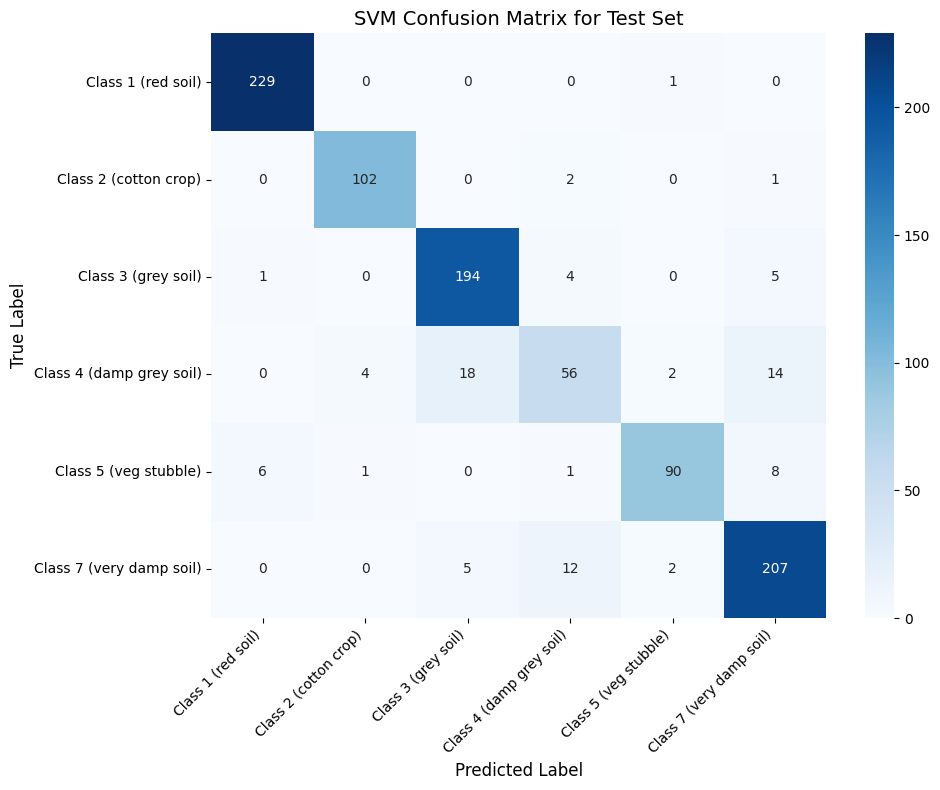

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Evaluating final SVM model on the test set...")
y_pred_test = final_svm_model.predict(X_test_scaled)

# Calculating final test accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")
print("--------------------")

print("\nClassification Report on Test Set")

# Define meaningful class names
# [1, 2, 3, 4, 5, 7] are the labels
class_labels_numeric = sorted(np.unique(y_data)) 
class_names_desc = [
    "Class 1 (red soil)", 
    "Class 2 (cotton crop)", 
    "Class 3 (grey soil)", 
    "Class 4 (damp grey soil)", 
    "Class 5 (veg stubble)", 
    "Class 7 (very damp soil)"
]

print(classification_report(y_test, y_pred_test, 
                            labels=class_labels_numeric, 
                            target_names=class_names_desc))

# Confusion Matrix
print("\nConfusion Matrix on Test Set")

cm = confusion_matrix(y_test, y_pred_test, labels=class_labels_numeric)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_desc, yticklabels=class_names_desc)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('SVM Confusion Matrix for Test Set', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout() 
plt.show()

In [5]:
print("----- Observations on Final SVM Test Results -----")
print()

print("1. Overall performance:")
print("   - Final test accuracy: 0.9098 (90.98%).")
print("   - Macro avg (precision/recall/f1): 0.90 / 0.88 / 0.89.")
print("   - Weighted avg (precision/recall/f1): 0.91 / 0.91 / 0.91.")
print("   - Test accuracy matches the best validation accuracy almost exactly, so the")
print("     hyper-parameter choice generalized rather than fitting the validation set.")
print()

print("2. Comparison with logistic regression:")
print("   - SVM 90.98% vs logistic regression 86.11%, a gain of about 4.9 points.")
print("   - The winning configuration was C=100 with an RBF kernel. A linear kernel")
print("     peaked at 0.8703 validation, close to logistic regression, which is the")
print("     expected result since both draw linear boundaries. The gain comes from the")
print("     RBF kernel, so the classes are not linearly separable in these 36 features.")
print()

print("3. Strongest classes:")
print("   - Class 1 (red soil) is the best: precision 0.97, recall 1.00, F1 0.98,")
print("     with 229 of 230 test samples correct.")
print("   - Class 2 (cotton crop): precision 0.95, recall 0.97, F1 0.96 (102 of 105).")
print("   - Both are spectrally distinctive, which makes them easy to separate.")
print()

print("4. Weakest class:")
print("   - Class 4 (damp grey soil) is the clear outlier: precision 0.75, recall 0.60,")
print("     F1 0.66 on 94 samples. It is also the smallest class in the test set.")
print("   - Its main confusion is with Class 7 (very damp soil): 14 true Class 4 samples")
print("     predicted as Class 7, and 12 in the opposite direction.")
print("   - The three grey-soil classes (3, 4, 7) differ by moisture, which shifts the")
print("     spectral signature only slightly, so the boundary between them is genuinely")
print("     narrow rather than badly modelled.")
print()

print("5. Where the SVM improved most over logistic regression:")
print("   - Class 4 F1 rose from 0.42 to 0.66 and Class 5 from 0.80 to 0.90.")
print("   - The gain is concentrated in exactly the classes logistic regression handled")
print("     worst, so the non-linear boundary is doing useful work on the hard cases")
print("     rather than sharpening ones that were already easy.")


----- Observations on Final SVM Test Results -----

1. Overall performance:
   - Final test accuracy: 0.9098 (90.98%).
   - Macro avg (precision/recall/f1): 0.90 / 0.88 / 0.89.
   - Weighted avg (precision/recall/f1): 0.91 / 0.91 / 0.91.
   - Test accuracy matches the best validation accuracy almost exactly, so the
     hyper-parameter choice generalized rather than fitting the validation set.

2. Comparison with logistic regression:
   - SVM 90.98% vs logistic regression 86.11%, a gain of about 4.9 points.
   - The winning configuration was C=100 with an RBF kernel. A linear kernel
     peaked at 0.8703 validation, close to logistic regression, which is the
     expected result since both draw linear boundaries. The gain comes from the
     RBF kernel, so the classes are not linearly separable in these 36 features.

3. Strongest classes:
   - Class 1 (red soil) is the best: precision 0.97, recall 1.00, F1 0.98,
     with 229 of 230 test samples correct.
   - Class 2 (cotton crop): pre